In [48]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings 
warnings.filterwarnings('ignore')

In [49]:
data_sales = pd.read_csv('AusApparalSales4thQrt2020.csv')

In [50]:
data_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Date    7560 non-null   object
 1   Time    7560 non-null   object
 2   State   7560 non-null   object
 3   Group   7560 non-null   object
 4   Unit    7560 non-null   int64 
 5   Sales   7560 non-null   int64 
dtypes: int64(2), object(4)
memory usage: 354.5+ KB


### a. Inspect the data manually to identify missing or incorrect information using the functions isna() and notna().

In [51]:
data_sales.isnull().sum()

Date     0
Time     0
State    0
Group    0
Unit     0
Sales    0
dtype: int64

#### There is no missing value in dataset 

### b. Based on your knowledge of data analytics, include your recommendations for treating missing and incorrect data (dropping the null values or filling them).
##### If there is a small percentage of data missing from the dataset and after carefully going through it if the data will not become bias the we can drop the rows. 
##### if large amount of data is missing from particular column but it is not critical for the analysis we can drop the entire column. 
##### if large amount of data is missing and its from critical column then we can check its skewness if coming normally distributed then we can use mean if right/left skewed then median to fill the column.

In [52]:
data_sales.head()

,Date,Time,State,Group,Unit,Sales
0,1-Oct-2020,Morning,WA,Kids,8,20000
1,1-Oct-2020,Morning,WA,Men,8,20000
2,1-Oct-2020,Morning,WA,Women,4,10000
3,1-Oct-2020,Morning,WA,Seniors,15,37500
4,1-Oct-2020,Afternoon,WA,Kids,3,7500


# c.	Choose a suitable data wrangling technique—either data standardization or normalization. Execute the preferred normalization method and present the resulting data. (Normalization is the preferred approach for this problem.)

In [53]:
data_sales['Sales_Normalise'] = (data_sales['Sales'] - data_sales['Sales'].min()) / (data_sales['Sales'].max()-data_sales['Sales'].min())

In [54]:
data_sales

,Date,Time,State,Group,Unit,Sales,Sales_Normalise
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873
...,...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,15,37500,0.206349
7557,30-Dec-2020,Evening,TAS,Men,15,37500,0.206349
7558,30-Dec-2020,Evening,TAS,Women,11,27500,0.142857


# Share your insights regarding the application of the GroupBy() function for either data chunking or merging, and offer a recommendation based on your analysis.
#### Groupby() function is used to apply mainly for aggregate function in which it can categorically take each value one by one and apply the aggregate function on each category. 

# Perform descriptive statistical analysis on the data in the Sales and Unit columns. Utilize techniques such as mean, median, mode, and standard deviation for this analysis.

In [55]:
unit_mean, unit_median,unit_stddev =data_sales['Unit'].agg(['mean','median','std'])
unit_mode = data_sales['Unit'].mode()[0]
print(f'Mean, Median, Mode, Standard Deviation of Unit:{unit_mean:.4f}, {unit_median}, {unit_mode}, {unit_stddev:.4f}')

Mean, Median, Mode, Standard Deviation of Unit:18.0054, 14.0, 9, 12.9014


In [136]:
sales_mean, sales_median,sales_stddev =data_sales['Sales'].agg(['mean','median','std'])
sales_mode = data_sales['Sales'].mode()[0]
print(f'Mean, Median, Mode, Standard Deviation of sales:{sales_mean:.4f}, {sales_median}, {sales_mode}, {sales_stddev:.4f}')

Mean, Median, Mode, Standard Deviation of sales:45013.5582, 35000.0, 22500, 32253.5069


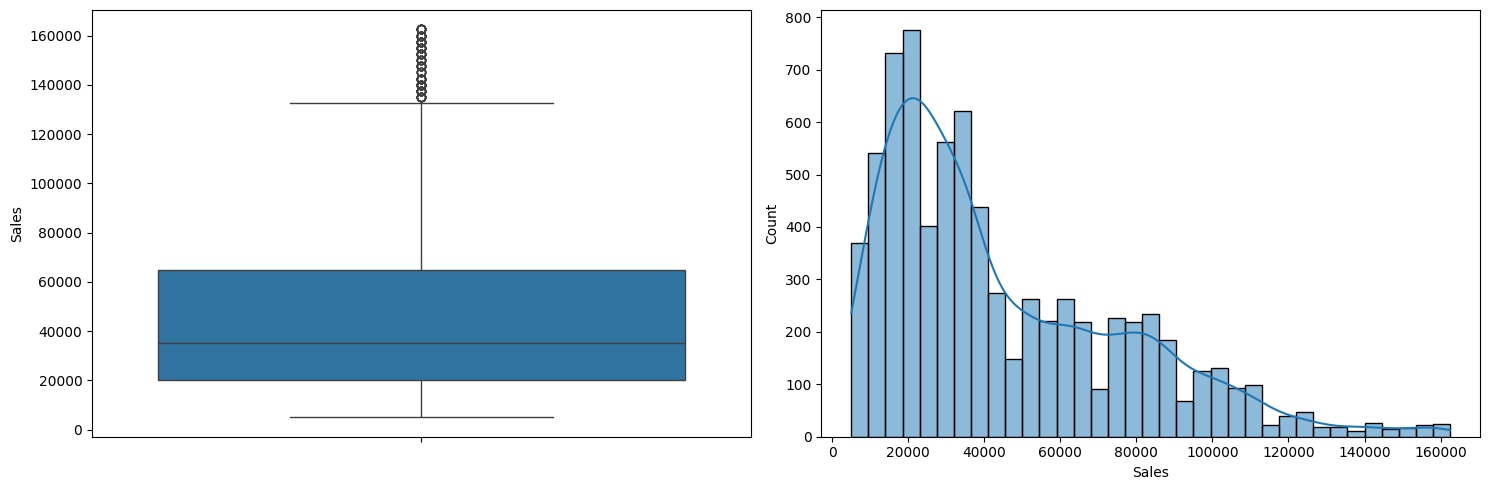

In [137]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data_sales['Sales'])

plt.subplot(1,2,2)
sns.histplot(data=data_sales,x=data_sales['Sales'],kde=True)
plt.tight_layout()
plt.show()

### Points
1. Box-Plot - show the data has outlier.
2. Histogram - data is right skewed.
--- So we are using IQR method to eliminate the outlier before proceding to further analysis.

In [58]:
def remove_outlier(data,column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 -q1 
    lower_bound = q1 - (1.5*iqr)
    upper_bound = q3 + (1.5*iqr) 
    data_cleaned = data[(data[column]>=lower_bound) & (data[column] <= upper_bound)]
    return data_cleaned

In [59]:
data_sales.shape

(7560, 7)

In [60]:
data_cleaned = remove_outlier(data_sales,'Sales')

In [61]:
data_cleaned.shape

(7437, 7)

# Identify the group with the highest sales and the group with the lowest sales based on the data provided.

In [62]:
totalSales_group = data_cleaned.groupby('Group')['Sales'].sum()

In [63]:
totalSales_group.idxmax()

' Kids'

In [64]:
totalSales_group.idxmin()

' Seniors'

### "Kids" has the highest sales and "Seniors" has the lowest sales in the Group of Men, Women, Kids and Seniors

# Generate weekly, monthly, and quarterly reports to document and present the results of the analysis conducted.

In [65]:
data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7437 entries, 0 to 7559
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             7437 non-null   object 
 1   Time             7437 non-null   object 
 2   State            7437 non-null   object 
 3   Group            7437 non-null   object 
 4   Unit             7437 non-null   int64  
 5   Sales            7437 non-null   int64  
 6   Sales_Normalise  7437 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 464.8+ KB


In [66]:
data_cleaned

,Date,Time,State,Group,Unit,Sales,Sales_Normalise
0,1-Oct-2020,Morning,WA,Kids,8,20000,0.095238
1,1-Oct-2020,Morning,WA,Men,8,20000,0.095238
2,1-Oct-2020,Morning,WA,Women,4,10000,0.031746
3,1-Oct-2020,Morning,WA,Seniors,15,37500,0.206349
4,1-Oct-2020,Afternoon,WA,Kids,3,7500,0.015873
...,...,...,...,...,...,...,...
7555,30-Dec-2020,Afternoon,TAS,Seniors,14,35000,0.190476
7556,30-Dec-2020,Evening,TAS,Kids,15,37500,0.206349
7557,30-Dec-2020,Evening,TAS,Men,15,37500,0.206349
7558,30-Dec-2020,Evening,TAS,Women,11,27500,0.142857


In [67]:
data_cleaned['Date'] = pd.to_datetime(data_cleaned['Date'], format='%d-%b-%Y',errors='coerce')

In [68]:
data_cleaned.set_index('Date',inplace=True)

In [69]:
data_cleaned

,Time,State,Group,Unit,Sales,Sales_Normalise
Date,,,,,,
2020-10-01,Morning,WA,Kids,8,20000,0.095238
2020-10-01,Morning,WA,Men,8,20000,0.095238
2020-10-01,Morning,WA,Women,4,10000,0.031746
2020-10-01,Morning,WA,Seniors,15,37500,0.206349
2020-10-01,Afternoon,WA,Kids,3,7500,0.015873
...,...,...,...,...,...,...
2020-12-30,Afternoon,TAS,Seniors,14,35000,0.190476
2020-12-30,Evening,TAS,Kids,15,37500,0.206349
2020-12-30,Evening,TAS,Men,15,37500,0.206349


In [70]:
weekly_sales = data_cleaned.resample('W')[['Sales','Unit']].sum()
weekly_sales = weekly_sales.reset_index()
weekly_sales

,Date,Sales,Unit
0,2020-10-04,15045000,6018
1,2020-10-11,27002500,10801
2,2020-10-18,26640000,10656
3,2020-10-25,26815000,10726
4,2020-11-01,21807500,8723
5,2020-11-08,20865000,8346
6,2020-11-15,21172500,8469
7,2020-11-22,21112500,8445
8,2020-11-29,21477500,8591
9,2020-12-06,26502500,10601


In [119]:
avg_weekly_sales = weekly_sales['Sales'].mean() 
avg_weekly_unit_sold = weekly_sales['Unit'].mean() 
highest_weekly_sales_value = weekly_sales['Sales'].max() 
highest_weekly_unit_sold =  weekly_sales.loc[weekly_sales['Sales'].idxmax(),'Unit']  
highest_weekly_sales_date = weekly_sales.loc[weekly_sales['Sales'].idxmax(),'Date'] 
lowest_weekly_sales_value = weekly_sales['Sales'].min()
lowest_weekly_unit_sold =  weekly_sales.loc[weekly_sales['Sales'].idxmin(),'Unit']  
lowest_weekly_sales_date = weekly_sales.loc[weekly_sales['Sales'].idxmin(),'Date']

In [120]:
print("Weekly Analysis Report")
print(f'The Average weekly sales value: AUD$ {avg_weekly_sales:.2f} and Average weekly unit sold: {avg_weekly_unit_sold.round()}')
print(f'The Best week for sales: {highest_weekly_sales_date:%Y-%b-%d}, the respective sales value for the week: AUD$ {highest_weekly_sales_value} and the unit sold that week: {highest_weekly_unit_sold}')
print(f'The Worst week for sales: {lowest_weekly_sales_date:%Y-%b-%d}, the respective sales value for the week: AUD$ {lowest_weekly_sales_value} and the unit sold that week: {lowest_weekly_unit_sold}')

Weekly Analysis Report
The Average weekly sales value: AUD$ 22997678.57 and Average weekly unit sold: 9199.0
The Best week for sales: 2020-Dec-20, the respective sales value for the week: AUD$ 27875000 and the unit sold that week: 11150
The Worst week for sales: 2021-Jan-03, the respective sales value for the week: AUD$ 12000000 and the unit sold that week: 4800


In [73]:
monthly_sales = data_cleaned.resample('ME')[['Sales','Unit']].sum()
monthly_sales = monthly_sales.reset_index()
monthly_sales

,Date,Sales,Unit
0,2020-10-31,114290000,45716
1,2020-11-30,90682500,36273
2,2020-12-31,116995000,46798


In [121]:
avg_monthly_sales = monthly_sales['Sales'].mean() 
avg_monthly_unit_sold = monthly_sales['Unit'].mean() 
highest_monthly_sales_value = monthly_sales['Sales'].max() 
highest_monthly_unit_sold =  monthly_sales.loc[monthly_sales['Sales'].idxmax(),'Unit']  
highest_monthly_sales_date = monthly_sales.loc[monthly_sales['Sales'].idxmax(),'Date'] 
lowest_monthly_sales_value = monthly_sales['Sales'].min()
lowest_monthly_unit_sold =  monthly_sales.loc[monthly_sales['Sales'].idxmin(),'Unit']  
lowest_monthly_sales_date = monthly_sales.loc[monthly_sales['Sales'].idxmin(),'Date']

In [138]:
print('Monthly Analysis Report')
print(f'The Average monthly sales value: AUD$ {avg_monthly_sales:.2f} and Average monthly unit sold: {avg_monthly_unit_sold.round()}')
print(f'The Best month for sales: {highest_monthly_sales_date:%Y-%b-%d}, the respective sales value for the month: AUD$ {highest_monthly_sales_value} and the unit sold that month: {highest_monthly_unit_sold}')
print(f'The Worst month for sales: {lowest_monthly_sales_date:%Y-%b-%d}, the respective sales value for the month: AUD$ {lowest_monthly_sales_value} and the unit sold that month: {lowest_monthly_unit_sold}')

Monthly Analysis Report
The Average monthly sales value: AUD$ 107322500.00 and Average monthly unit sold: 42929.0
The Best month for sales: 2020-Dec-31, the respective sales value for the month: AUD$ 116995000 and the unit sold that month: 46798
The Worst month for sales: 2020-Nov-30, the respective sales value for the month: AUD$ 90682500 and the unit sold that month: 36273


In [94]:
quater_sales = data_cleaned.resample('QE')[['Sales','Unit']].sum()
quater_sales = quater_sales.reset_index()
quater_sales

,Date,Sales,Unit
0,2020-12-31,321967500,128787


In [123]:
quaterly_sales_value = quater_sales['Sales'].max() 
quaterly_unit_sold = quater_sales['Unit'].max()  

In [139]:
print('Quaterly Analysis Report')
print(f'The quaterly sales value: AUD$ {quaterly_sales_value} and total unit sold in the quater: {quaterly_unit_sold} ')

Quaterly Analysis Report
The quaterly sales value: AUD$ 321967500 and total unit sold in the quater: 128787 


# 	State-wise sales analysis for different demographic groups (kids, women, men, and seniors).

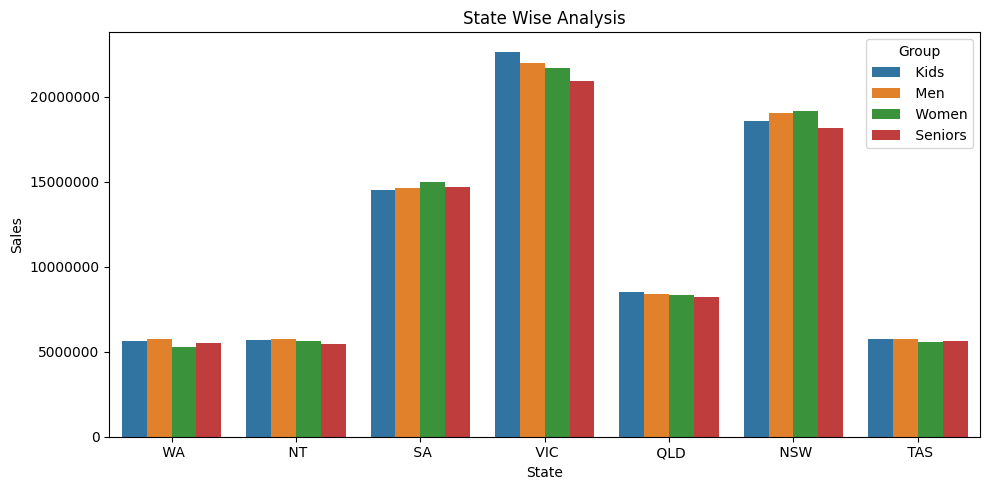

In [128]:
plt.figure(figsize=(10,5))
plt.ticklabel_format(style='plain', axis='y')
sns.barplot(data=data_cleaned,x='State',y='Sales',hue='Group',errorbar=None,estimator=sum) 
plt.title("State Wise Analysis")
plt.tight_layout()
plt.show()

# Group-wise sales analysis (Kids, Women, Men, and Seniors) across various states.

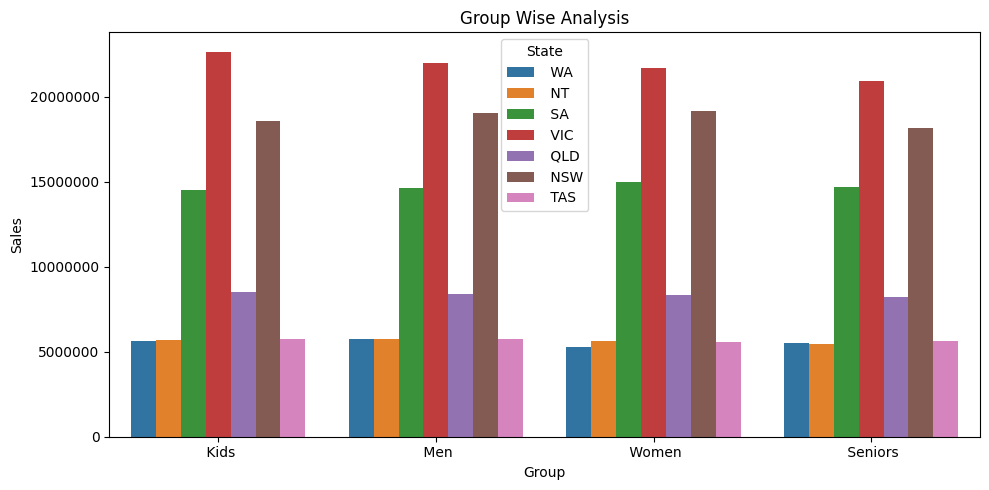

In [129]:
plt.figure(figsize=(10,5))
plt.ticklabel_format(style='plain', axis='y')
sns.barplot(data=data_cleaned,x='Group',y='Sales',hue='State',errorbar=None,estimator=sum) 
plt.title("Group Wise Analysis")
plt.tight_layout()
plt.show()

# Time-of-the-day analysis: Identify peak and off-peak sales periods to facilitate strategic planning for S&M teams. This information aids in designing programs like hyper-personalization and Next Best Offers to enhance sales.

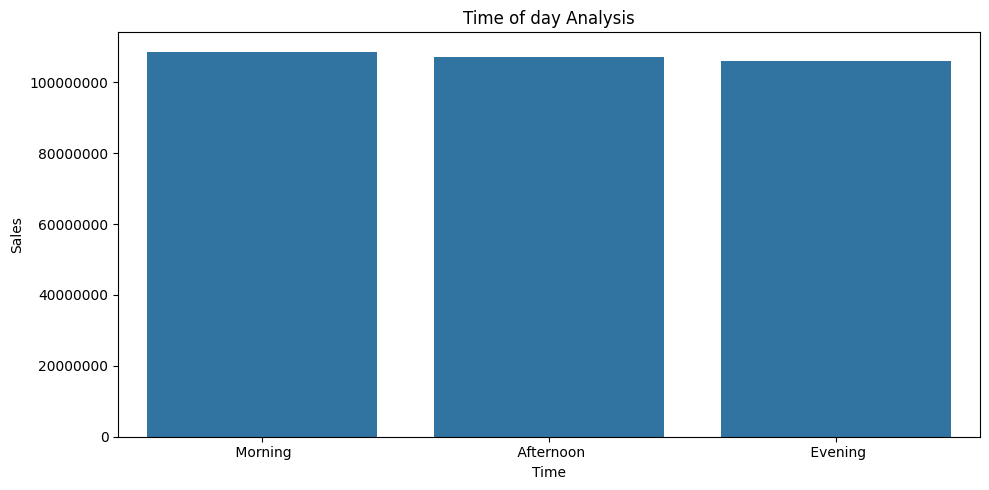

In [142]:
plt.figure(figsize=(10,5))
plt.ticklabel_format(style='plain', axis='y')
sns.barplot(data=data_cleaned,x='Time',y='Sales',errorbar=None,estimator=sum) 
plt.title("Time of day Analysis")
plt.tight_layout()
plt.show()

### As we can see in the graph there is no much difference in the sales throughout the Time of the day

# Ensure the visualization is clear and accessible for effective decision-making by the head of sales and marketing (S&M).
## The dashboard must contain daily, weekly, monthly, and quarterly charts.


In [131]:
daily_sales = data_cleaned.resample('D')[['Sales','Unit']].sum()
daily_sales = daily_sales.reset_index() 
daily_sales

,Date,Sales,Unit
0,2020-10-01,3720000,1488
1,2020-10-02,3715000,1486
2,2020-10-03,3890000,1556
3,2020-10-04,3720000,1488
4,2020-10-05,3862500,1545
...,...,...,...
86,2020-12-26,3965000,1586
87,2020-12-27,3772500,1509
88,2020-12-28,3695000,1478
89,2020-12-29,4032500,1613


# Daily Sales and Unit Sold Dashboard

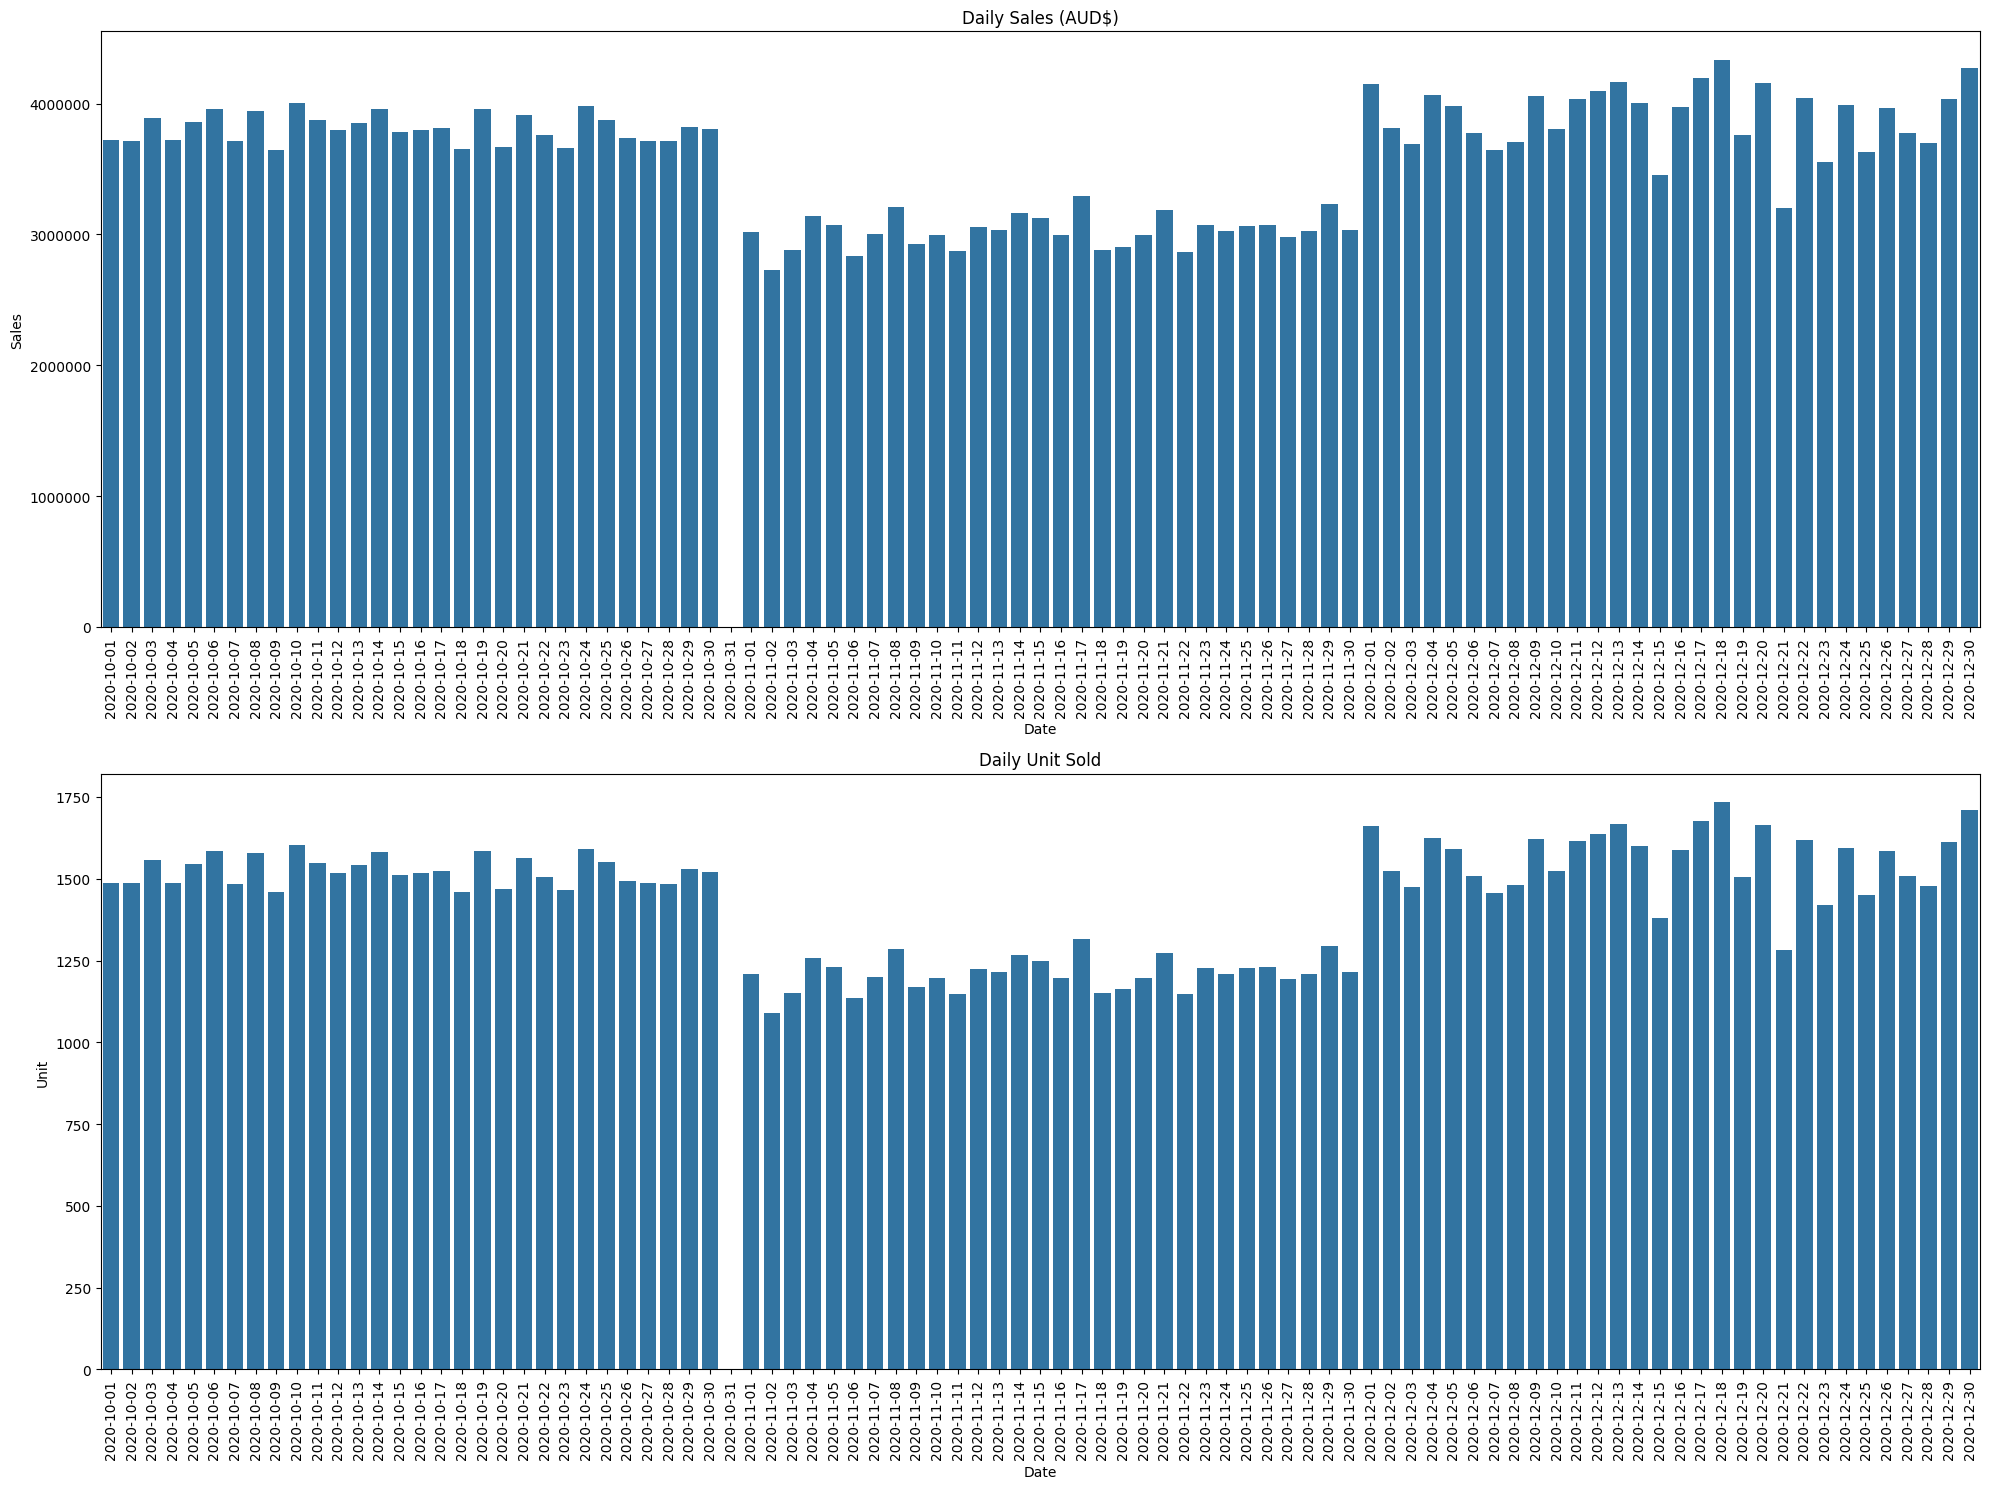

In [132]:
plt.figure(figsize=(20,15))
plt.subplot(2,1,1)
sns.barplot(data=daily_sales,x='Date', y='Sales')
plt.title("Daily Sales (AUD$)")
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation = 90)
plt.subplot(2,1,2)
sns.barplot(data=daily_sales,x='Date', y='Unit')
plt.title("Daily Unit Sold")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

# Weekly Sales and Unit Sold Dashboard

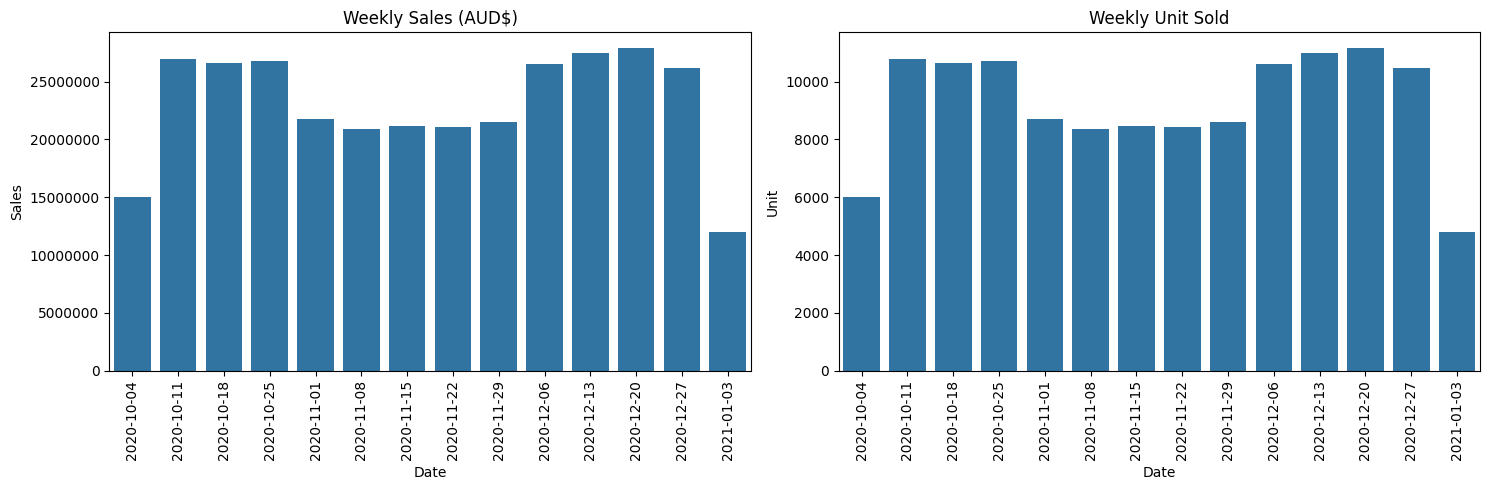

In [133]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.barplot(data=weekly_sales,x='Date', y='Sales')
plt.title("Weekly Sales (AUD$)")
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation = 90)
plt.subplot(1,2,2)
sns.barplot(data=weekly_sales,x='Date', y='Unit')
plt.title("Weekly Unit Sold")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

# Monthly Sales and Unit Sold Dashboard

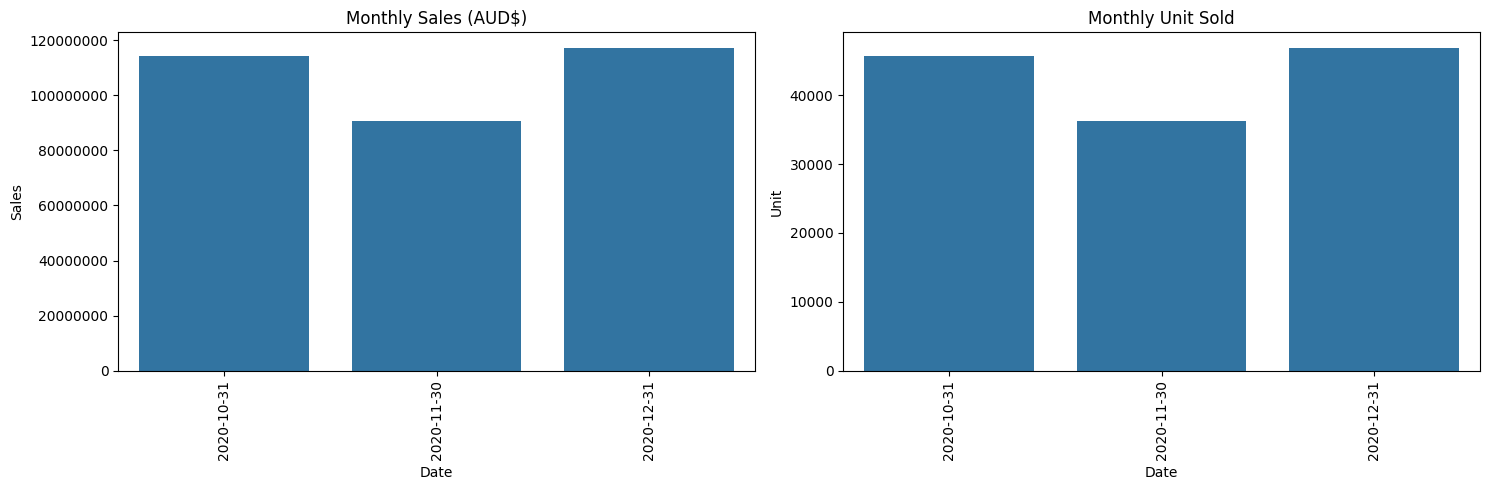

In [134]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.barplot(data=monthly_sales,x='Date', y='Sales')
plt.title("Monthly Sales (AUD$)")
plt.ticklabel_format(style='plain',axis='y')
plt.xticks(rotation = 90)
plt.subplot(1,2,2)
sns.barplot(data=monthly_sales,x='Date', y='Unit')
plt.title("Monthly Unit Sold")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()

# Quaterly Sales and Unit Sold Dashboard

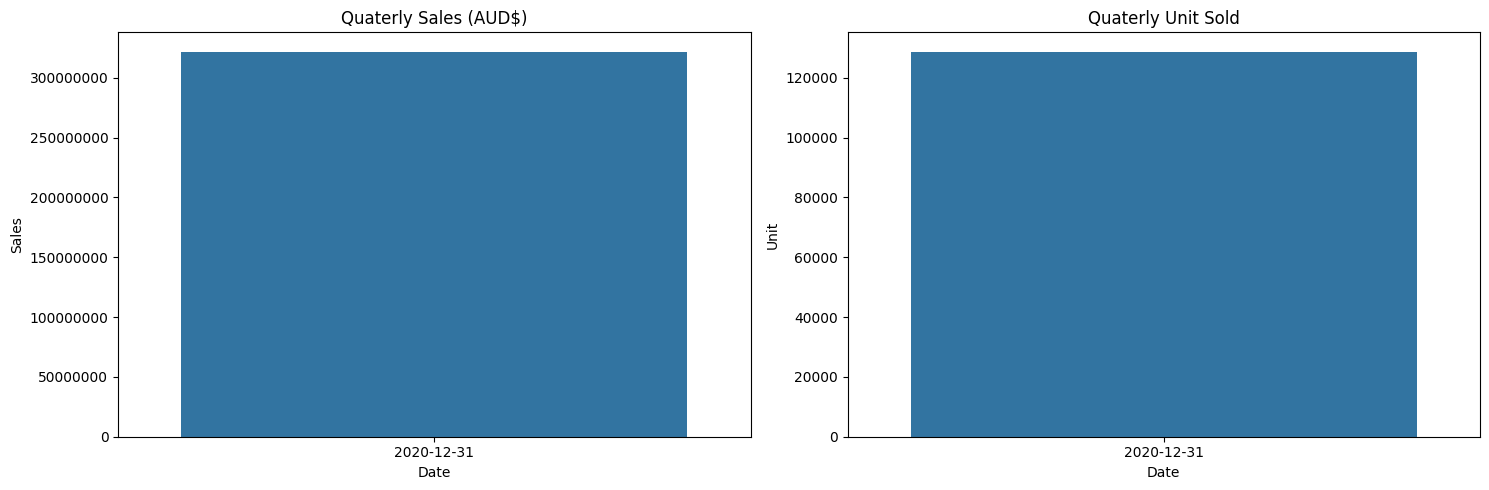

In [143]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1)
sns.barplot(data=quater_sales,x='Date', y='Sales')
plt.title("Quaterly Sales (AUD$)")
plt.ticklabel_format(style='plain',axis='y')
plt.subplot(1,2,2)
sns.barplot(data=quater_sales,x='Date', y='Unit')
plt.title("Quaterly Unit Sold")
plt.tight_layout()
plt.show()